In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 1.6 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 2.1 MB/s eta 0:00:01
   -------------------------- ------------- 1.3/2.0 MB 1.8 MB/s eta 0:00:01
   ------------------------------------- -- 1.8/2.0 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 1.8 MB/s eta 0:00:00

   ------ --------------------------------- 1/6 [websockets]
   ------ --------------------------------- 1/6 [websockets]
   ------------- -------------------------- 2/6 [peewee]
   ------------- -------------------------- 2/6 [peewee]
   ------------- -------------------------- 2/6 [peewee]
  Attempting uninstall: cffi
   ------------- -------------------------- 2/6 [peewee]
    Found existing installation: cffi 1.17.1
   ------------- -------------------------- 2/6 [peewee]


In [2]:
import yfinance as yf

df = yf.download("NPN.JO", start="2018-01-01", end="2026-08-13")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open   Volume
Ticker            NPN.JO        NPN.JO        NPN.JO        NPN.JO   NPN.JO
Date                                                                       
2018-01-02  45017.335938  45115.519404  43999.670033  44076.983508  7402232
2018-01-03  45886.031250  46083.905656  44672.377087  45609.456974  7974038
2018-01-04  45718.957031  46828.768894  44736.868432  46613.668156  9841050
2018-01-05  45464.128906  45691.168173  44755.220900  45496.312589  6273840
2018-01-08  45220.117188  45803.438195  45042.359048  45640.887345  5061349


In [4]:
df.to_csv("naspers_jse.csv")

In [5]:
!pip install pandas numpy scikit-learn xgboost matplotlib

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 2.2 MB/s eta 0:00:22
   - -------------------------------------- 1.3/48.9 MB 2.2 MB/s eta 0:00:22
   - -------------------------------------- 1.6/48.9 MB 1.6 MB/s eta 0:00:30
   -- ------------------------------------- 2.6/48.9 MB 2.3 MB/s eta 0:00:20
   -- ------------------------------------- 3.1/48.9 MB 2.4 MB/s eta 0:00:19
   -- ------------------------------------- 3.4/48.9 MB 2.4 MB/s eta 0:00:20
   --- ------------------------------------ 4.2/48.9 MB 2.3 MB/s eta 0:00:20
   --- ------------------------------------ 4.7/48.9 MB 2.4 MB/s eta 0:00:19
   ---- ----------------------------------- 5.2/48.9 MB 2.4 MB/s eta 0:00:19
   ---- -------------------

In [7]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\user
['.anaconda', '.android', '.conda', '.condarc', '.continuum', '.copilot', '.emulator_console_auth_token', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', '.virtual_documents', '.vscode', '.vscode-R', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'App Dev Project', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Customer Churn EDA.ipynb', 'Desktop', 'Documents', 'Downloads', 'Fashion models .ipynb', 'Favorites', 'IntelGraphicsProfiles', 'iStyla Model.ipynb', 'istyla_fashion_importance_chart.png', 'istyla_model_chart.png', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'naspers_jse.csv', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{5715c5f2-da4e-11ef-a17a-f9bdb1a4e24f}.TM.blf', 'NTUSER.DAT{5715c5f2-da4e-11ef-a17a-f9bdb1a4e24f}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{5715c5f2-da4e-11ef-a17a-f9bdb1a4e24f}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("naspers_jse.csv", skiprows=[1, 2])
df.rename(columns={"Price": "Date"}, inplace=True)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.shape)
print("Missing values:\n", df.isna().sum())

        Date         Close          High           Low          Open   Volume
0 2018-01-02  45017.335938  45115.519404  43999.670033  44076.983508  7402232
1 2018-01-03  45886.031250  46083.905656  44672.377087  45609.456974  7974038
2 2018-01-04  45718.957031  46828.768894  44736.868432  46613.668156  9841050
3 2018-01-05  45464.128906  45691.168173  44755.220900  45496.312589  6273840
4 2018-01-08  45220.117188  45803.438195  45042.359048  45640.887345  5061349
(2152, 6)
Missing values:
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [9]:
# Daily return
df["Return"] = df["Close"].pct_change()

# Lagged returns
for lag in [1, 2, 3, 5]:
    df[f"Return_lag{lag}"] = df["Return"].shift(lag)

# Moving averages
df["MA5"] = df["Close"].rolling(5).mean()
df["MA10"] = df["Close"].rolling(10).mean()
df["MA20"] = df["Close"].rolling(20).mean()

# Price relative to moving averages (scale-free)
df["Close_to_MA5"] = df["Close"] / df["MA5"] - 1
df["Close_to_MA20"] = df["Close"] / df["MA20"] - 1

# Rolling volatility
df["Volatility10"] = df["Return"].rolling(10).std()

# RSI (14-day)
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = -delta.where(delta < 0, 0).rolling(14).mean()
rs = gain / loss
df["RSI14"] = 100 - (100 / (1 + rs))

# Volume features
df["Volume_change"] = df["Volume"].pct_change()
df["Volume_MA5"] = df["Volume"].rolling(5).mean()

# High-Low spread
df["HL_spread"] = (df["High"] - df["Low"]) / df["Close"]

df.head()

,Date,Close,High,Low,Open,Volume,Return,Return_lag1,Return_lag2,Return_lag3,...,MA5,MA10,MA20,Close_to_MA5,Close_to_MA20,Volatility10,RSI14,Volume_change,Volume_MA5,HL_spread
0,2018-01-02,45017.335938,45115.519404,43999.670033,44076.983508,7402232,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.024787
1,2018-01-03,45886.031250,46083.905656,44672.377087,45609.456974,7974038,0.019297,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.077248,NaN,0.030762
2,2018-01-04,45718.957031,46828.768894,44736.868432,46613.668156,9841050,-0.003641,0.019297,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.234136,NaN,0.045756
3,2018-01-05,45464.128906,45691.168173,44755.220900,45496.312589,6273840,-0.005574,-0.003641,0.019297,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.362483,NaN,0.020586
4,2018-01-08,45220.117188,45803.438195,45042.359048,45640.887345,5061349,-0.005367,-0.005574,-0.003641,0.019297,...,45461.314063,NaN,NaN,-0.005306,NaN,NaN,NaN,-0.193261,7310501.8,0.016831


In [10]:
df["Target_return"] = df["Close"].shift(-1) / df["Close"] - 1
df["Target_direction"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

df_model = df.dropna().reset_index(drop=True)

feature_cols = [
    "Return_lag1", "Return_lag2", "Return_lag3", "Return_lag5",
    "Close_to_MA5", "Close_to_MA20", "Volatility10", "RSI14",
    "Volume_change", "Volume_MA5", "HL_spread"
]

split_date = "2025-01-01"
train = df_model[df_model["Date"] < split_date]
test = df_model[df_model["Date"] >= split_date]

X_train, y_train_ret = train[feature_cols], train["Target_return"]
X_test, y_test_ret = test[feature_cols], test["Target_return"]
y_train_dir, y_test_dir = train["Target_direction"], test["Target_direction"]

print(f"Train: {len(train)} rows, Test: {len(test)} rows")

Train: 1730 rows, Test: 402 rows


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

naive_pred = np.zeros(len(y_test_ret))
print(f"Naive baseline -> MAE: {mean_absolute_error(y_test_ret, naive_pred):.5f}, R2: 0.0000")

lr = LinearRegression()
lr.fit(X_train, y_train_ret)
lr_pred = lr.predict(X_test)
print(f"Linear Regression -> MAE: {mean_absolute_error(y_test_ret, lr_pred):.5f}, R2: {r2_score(y_test_ret, lr_pred):.4f}")

xgb_reg = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_reg.fit(X_train, y_train_ret)
xgb_pred = xgb_reg.predict(X_test)
print(f"XGBoost -> MAE: {mean_absolute_error(y_test_ret, xgb_pred):.5f}, R2: {r2_score(y_test_ret, xgb_pred):.4f}")

Naive baseline -> MAE: 0.01644, R2: 0.0000
Linear Regression -> MAE: 0.01658, R2: -0.0036
XGBoost -> MAE: 0.01672, R2: -0.0092


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline_acc = max(y_test_dir.mean(), 1 - y_test_dir.mean())
print(f"Naive baseline -> Accuracy: {baseline_acc:.4f}")

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train_dir)
print(f"Logistic Regression -> Accuracy: {accuracy_score(y_test_dir, log_reg.predict(X_test)):.4f}")

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train_dir)
print(f"Random Forest -> Accuracy: {accuracy_score(y_test_dir, rf.predict(X_test)):.4f}")

xgb_clf = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42, eval_metric="logloss")
xgb_clf.fit(X_train, y_train_dir)
xgb_pred_dir = xgb_clf.predict(X_test)
print(f"XGBoost -> Accuracy: {accuracy_score(y_test_dir, xgb_pred_dir):.4f}")

print("\n", classification_report(y_test_dir, xgb_pred_dir, target_names=["Down", "Up"]))

Naive baseline -> Accuracy: 0.5124
Logistic Regression -> Accuracy: 0.4876
Random Forest -> Accuracy: 0.5299
XGBoost -> Accuracy: 0.5224

               precision    recall  f1-score   support

        Down       0.51      0.59      0.55       196
          Up       0.54      0.46      0.49       206

    accuracy                           0.52       402
   macro avg       0.52      0.52      0.52       402
weighted avg       0.52      0.52      0.52       402



In [13]:
importances = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

Volume_change    0.116243
Return_lag3      0.101539
RSI14            0.101261
Return_lag1      0.100563
HL_spread        0.095214
Volume_MA5       0.085495
Volatility10     0.084855
Close_to_MA20    0.081735
Return_lag2      0.081003
Return_lag5      0.076922
Close_to_MA5     0.075171
dtype: float32


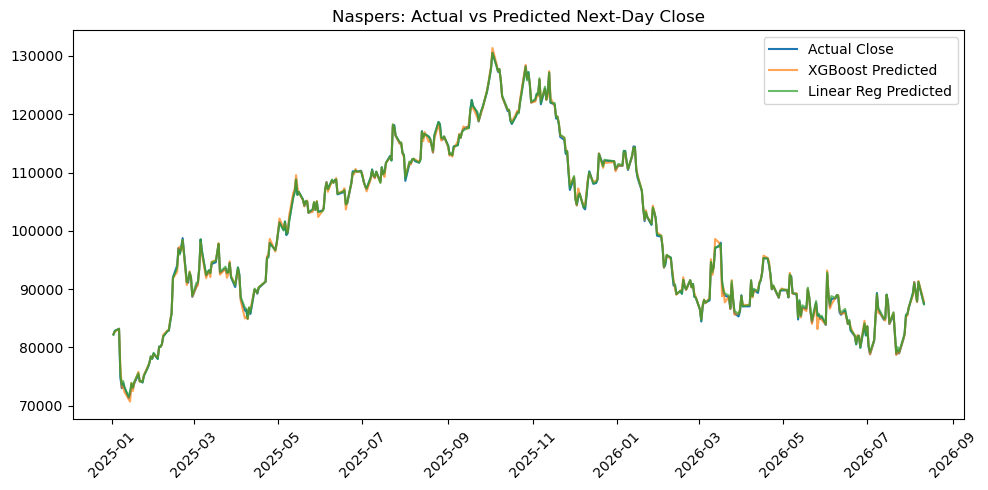

In [14]:
import matplotlib.pyplot as plt

results = test[["Date", "Close"]].copy()
results["XGB_pred_price"] = test["Close"].values * (1 + xgb_pred)
results["LR_pred_price"] = test["Close"].values * (1 + lr_pred)

plt.figure(figsize=(10, 5))
plt.plot(results["Date"], results["Close"], label="Actual Close")
plt.plot(results["Date"], results["XGB_pred_price"], label="XGBoost Predicted", alpha=0.7)
plt.plot(results["Date"], results["LR_pred_price"], label="Linear Reg Predicted", alpha=0.7)
plt.legend()
plt.title("Naspers: Actual vs Predicted Next-Day Close")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()